# XMEAS10 · Gate 推理结果作图台

按 **index** 或 **run+local** 交互作图。三种主图:

1. **`plot_forecast(...)`** — 预测曲线 vs 真值(gate 深蓝主角;对比方法橙/深青/紫/红 高对比,经色盲可分性验证),底部可叠加 **gate 逐步路由权重条**(与曲线同色);标出 ±3σ 控制限(LCL/UCL)、预测原点、报警区。
2. **`plot_gate_weights(...)`** — 单个窗口的 gate 路由权重详图(堆叠面积 + 各专家权重曲线)。
3. **`plot_mean_routing(...)`** — 全测试集平均路由(复现"近端合议 → 中段 diff → 远端 raw"三段式)。
   辅助:**`alarm_windows(run,...)`** 快速定位"真值会越限"的报警相关窗口。

**索引约定**:测试集 3620 个窗口 = Run9(全局 index 0–1809)+ Run10(1810–3619)。
窗口 `t` 的预测 horizon(15 步 = 45 min,3 min/步)从对应 csv 第 `96+t_local` 行开始;IDV13 在每个 run 第 600 行(30 h)注入。

> ⚠️ 运行前请把 kernel 切到含 numpy/pandas/matplotlib 的环境(如 `tsfm`)。若默认 `python3` kernel 缺包,终端里执行:
> `/home/aicode/miniconda3/envs/tsfm/bin/python -m ipykernel install --user --name tsfm --display-name "Python (tsfm)"`,再在右上角选 `Python (tsfm)`。
> 图内文字用英文(matplotlib 默认字体无中文字形);说明与打印用中文。

In [1]:
# === 配置:路径、常量、配色(与 figures/.../index_plot/plot_index.py 保持一致)===
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

RESULTS = Path("/home/aicode/sherwin/TSFM/results")
CSV_DIR = Path("/home/aicode/sherwin/dataset/TEP/csv_5var")            # mag=100 (训练/推理用)
LOWMAG_DIR = Path("/home/aicode/sherwin/dataset/TEP/csv_5var_lowmag")  # mag=25/50/75 (仅真值序列, 无推理)
HERE    = Path("/home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10")

TARGET_COL      = "XMEAS10 Purge Rate"
TRAIN_RUNS      = range(1, 8)     # Run1-7 定 ±3σ 控制限
HORIZON         = 15              # 融合/评测/报警用的预测步 (= 45 min)
SEQ_LEN         = 96              # 上下文长度 -> 窗口 t 的 horizon 从 csv 第 96+t_local 行开始
PRED_LEN        = 96              # 保存的预测长度(窗口数 = 行数 - SEQ_LEN - PRED_LEN + 1)
WINDOWS_PER_RUN = 1810            # mag=100 每 run 窗口数(mag=25/50/75 为 1809, 见 windows_per_run())
CONTEXT_SHOW    = 30              # 图上画出的历史点数
STEP_MIN        = 3.0             # 采样 0.05 h = 3 min/步
FAULT_ROW       = 600             # IDV13 在每个 run 第 600 行(30 h)注入
RATIOS          = ["r0p01","r0p02","r0p05","r0p1","r0p25","r0p5","r1p0"]
EXPERTS         = ["diff","raw","time_moe","sundial"]   # weights.npy 最后一维顺序(见 meta.json)
MAG             = 25    # 推理作图默认故障幅度: 100=原始满幅, 25=小幅度(已跑推理; 50/75 未跑)

IKB="#002FA7"; INK="#0a0a0a"; GREY_DARK="#5c5c5c"; GREY_MID="#8f8f8d"
GREY_LIGHT="#c4c4c2"; PAPER="#ffffff"
# 对比方法高对比配色(经 dataviz validate_palette.js 验证:4 专家 CVD worst ΔE 26.1, 对比全 >=3:1)。
# 权重堆叠条与上方预测曲线共用这套颜色,保证同色对应。
EXPERT_COLORS = {"diff":"#eb6834", "raw":"#0f8f66", "time_moe":"#4a3aa7", "sundial":"#e34948"}

# --- mag=25 三种 gate 对比(新报警感知 gate vs exp A / exp B),Run9-10 mag=25 ---
TSFM_ROOT = Path("/home/aicode/sherwin/TSFM")
GATE_VARIANTS = {
    "expA":  "ensemble_Gate_XMEAS10_mag25_test",     # mag100 专家 + MSE gate(部署的集成测小故障)
    "expB":  "ensemble_Gate_XMEAS10_train25_test",   # mag25 专家 + MSE gate(全 mag25 重训)
    "alarm": "ensemble_Gate_alarm_XMEAS10_test",     # mag25 专家 + 报警感知 gate(新方法)
}
GATE_LABELS  = {"expA":"exp A (mag100 experts, MSE)", "expB":"exp B (mag25 experts, MSE)", "alarm":"alarm gate (new)"}
GATE_VCOLORS = {"expA":GREY_MID, "expB":EXPERT_COLORS["raw"], "alarm":IKB}

DL_MODELS  = ["CNNLSTM","DiPCALSTM","LSTMGRU","STAConvBiLSTM","TCNTransformer"]
DL_PALETTE = {"CNNLSTM":"#b0803c","DiPCALSTM":"#7a9a6d","LSTMGRU":"#9a6d8f",
              "STAConvBiLSTM":"#3c7f8f","TCNTransformer":"#c25b4e"}
PRESETS = {
    "gate_experts": ["gate","diff","raw","time_moe","sundial"],
    "gate_only":    ["gate"],
    "main":         ["gate","diff","raw","time_moe","sundial","TCNTransformer_diff","STAConvBiLSTM_diff"],
    "all":          ["gate","diff","raw","time_moe","sundial"]
                    + [f"{m}_{d}" for m in DL_MODELS for d in ("diff","raw")],
}
plt.rcParams.update({"font.family":"sans-serif",
                     "font.sans-serif":["Inter","Helvetica Neue","Arial","DejaVu Sans"],
                     "axes.linewidth":0.8})
print("python :", sys.executable)
print("results:", RESULTS.exists(), "| csv:", CSV_DIR.exists(), "| out:", HERE)

python : /home/aicode/miniconda3/bin/python3
results: True | csv: True | out: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10


In [2]:
# === 数据加载 helpers(mag 感知: 100=原始满幅, 25=小幅度推理)===
def _csv_series(run_no, mag=100):
    "真值 XMEAS10 序列。mag=100 读 csv_5var;mag=25/50/75 读 csv_5var_lowmag。"
    d = CSV_DIR if mag == 100 else LOWMAG_DIR
    hits = sorted(d.glob(f"*IDV13*_{mag}_Run{run_no}.csv"))
    if not hits:
        raise FileNotFoundError(f"缺少 mag={mag} Run{run_no} 的 csv(在 {d})")
    return pd.read_csv(hits[0])[TARGET_COL].to_numpy(float)

def _lowmag_result_name(key, mag):
    return {"gate": f"ensemble_Gate_XMEAS10_mag{mag}_test", "raw": f"mag{mag}_raw_test",
            "diff": f"mag{mag}_diff_test", "time_moe": f"fm_time_moe_xmeas10_mag{mag}_test",
            "sundial": f"fm_sundial_xmeas10_mag{mag}_test"}.get(key)

def result_dir(key, ratio="r1p0", mag=100):
    "解析某方法在某 ratio/mag 下装着 pred.npy 的 results/ 目录。"
    if mag != 100:                              # 小幅度: 只跑了 gate + 4 专家(无 DL baselines / 无 ratio 维度)
        name = _lowmag_result_name(key, mag)
        if name is None:
            raise FileNotFoundError(f"mag={mag} 只有 gate+4专家的推理, 没有 '{key}'(如 DL baseline)")
        d = RESULTS / name
        if not d.exists():
            raise FileNotFoundError(f"缺 {d} —— 该 mag 尚未跑推理")
        return d
    if key == "gate":     return RESULTS / f"ensemble_Gate_XMEAS10_{ratio}_test"
    if key == "time_moe": return RESULTS / "fm_time_moe_xmeas10_zeroshot_test"   # 与 ratio 无关
    if key == "sundial":  return RESULTS / "fm_sundial_xmeas10_zeroshot_test"    # 与 ratio 无关
    if key in ("diff","raw"):
        pat = f"forecast_TEP_IDV13_XMEAS10_5var_{key}_few_{ratio}_timer_xl_*"
    else:
        model, dom = key.rsplit("_", 1)
        pat = f"long_term_forecast_TEP_IDV13_XMEAS10_5var_{dom}_{model}_{ratio}_{model}_*"
    hits = sorted(RESULTS.glob(pat))
    if not hits:
        raise FileNotFoundError(f"没有 {key} @ {ratio} 的结果目录 (pattern {pat})")
    return hits[0]

def load_pred(key, ratio, index, mag=100):
    "某方法在某窗口的 15 步预测。"
    return np.load(result_dir(key, ratio, mag) / "pred.npy")[index].reshape(-1)[:HORIZON].astype(float)

def load_gate_weights(ratio, index, mag=100):
    "(15,4) gate 路由权重: 预测步 × [diff,raw,time_moe,sundial]; 每步 4 权重和为 1。"
    return np.load(result_dir("gate", ratio, mag) / "weights.npy")[index].astype(float)

def windows_per_run(mag=100):
    "每个 run 的窗口数: mag=100 -> 1810 (2001 行), mag=25/50/75 -> 1809 (2000 行)。"
    return len(_csv_series(9, mag)) - SEQ_LEN - PRED_LEN + 1

def resolve_index(index=None, run=None, local=None, mag=100):
    "全局窗口号 index,或 (run∈{9,10}, local)。注意 mag=100 每 run 1810,mag=25/50/75 为 1809。"
    if index is not None:
        return int(index)
    if run in (9, 10) and local is not None:
        return int(local) + (0 if run == 9 else windows_per_run(mag))
    raise ValueError("请给 index=,或同时给 run=9/10 和 local=")

def window_info(index, mag=100):
    wpr = windows_per_run(mag)
    run_no, local = (9, index) if index < wpr else (10, index - wpr)
    origin_h = (SEQ_LEN + local) * 0.05
    state = "post-fault" if origin_h >= FAULT_ROW * 0.05 else "pre-fault"
    return dict(index=index, run=run_no, local=local, origin_h=origin_h, state=state, mag=mag)

def load_truth_around(index, mag=100):
    "从原始 csv 取 (上下文尾部, 15 步真值未来)。"
    info = window_info(index, mag); series = _csv_series(info["run"], mag)
    start = SEQ_LEN + info["local"]
    ctx = series[max(0, start - CONTEXT_SHOW):start]
    fut = series[start:start + HORIZON]
    return ctx, fut

def control_limits():
    "±3σ 控制限,取自 mag=100 Run1-7 故障前(<30 h)数据(与幅度无关, 四档共用)。"
    v = np.concatenate([_csv_series(n, 100)[:FAULT_ROW] for n in TRAIN_RUNS])
    return float(v.mean() - 3 * v.std()), float(v.mean() + 3 * v.std())

def control_limits_mag25():
    "mag=25 的 ±3σ(读 setting/limits_tep_xmeas10_mag25.csv,与报警 gate 最终评测一致的限)。"
    df = pd.read_csv(TSFM_ROOT / "setting/limits_tep_xmeas10_mag25.csv", index_col=0)
    return float(df.loc[TARGET_COL].iloc[2]), float(df.loc[TARGET_COL].iloc[1])   # L, H

def load_gate_variant(variant, index):
    "三种 gate 之一在 Run9-10 mag=25 某窗口的 15 步预测(variant ∈ expA/expB/alarm)。"
    return np.load(RESULTS / GATE_VARIANTS[variant] / "pred.npy")[index].reshape(-1)[:HORIZON].astype(float)

LCL, UCL = control_limits()
LCL25, UCL25 = control_limits_mag25()
print(f"控制限(mag100 默认)LCL={LCL:.4f} UCL={UCL:.4f}  | mag25 限 LCL={LCL25:.4f} UCL={UCL25:.4f}")
print(f"推理作图默认 MAG={MAG}% (每 run {windows_per_run(MAG)} 窗口)")

控制限(mag100 默认)LCL=0.1802 UCL=0.2438  | mag25 限 LCL=0.1817 UCL=0.2415
推理作图默认 MAG=25% (每 run 1809 窗口)


In [3]:
# === 主作图函数:预测曲线(可选叠加 gate 逐步路由权重条)===
def style_for(key):
    if key == "gate":     return dict(color=IKB, lw=2.8, marker="o", ms=5, mfc=IKB, mec="white", mew=1, zorder=8, label="Gate fusion")
    if key == "diff":     return dict(color=EXPERT_COLORS["diff"], lw=1.9, marker="o", ms=4.0, mfc=PAPER, mew=1.2, zorder=6, label="Timer-XL diff")
    if key == "raw":      return dict(color=EXPERT_COLORS["raw"], lw=1.9, marker="s", ms=3.6, mfc=PAPER, mew=1.2, zorder=5, label="Timer-XL raw")
    if key == "time_moe": return dict(color=EXPERT_COLORS["time_moe"], lw=1.8, ls=(0,(5,2.5)), zorder=4, label="Time-MoE zero-shot")
    if key == "sundial":  return dict(color=EXPERT_COLORS["sundial"], lw=1.8, ls=(0,(1,1.6)), zorder=4, label="Sundial zero-shot")
    model, dom = key.rsplit("_", 1)
    return dict(color=DL_PALETTE[model], lw=1.3, alpha=0.9, ls="-" if dom == "diff" else (0,(5,2)), zorder=3, label=f"{model} {dom}")

def plot_forecast(index=None, run=None, local=None, ratio="r1p0",
                  models="gate_experts", show_weights=True, limits=True,
                  ylim=None, mag=MAG, save=False):
    '''一个窗口的预测对比图。
    index=全局窗口号  或  run=9/10 + local。mag=25(默认)小幅度 / mag=100 原始满幅。
    mag=25 只有 gate+4专家(models 用 'gate_experts'/'gate_only');mag=100 才有 DL baselines。
    show_weights=True 时底部叠加 gate 逐步路由权重堆叠条。save=True 存 png+pdf。'''
    idx = resolve_index(index, run, local, mag); info = window_info(idx, mag)
    keys = PRESETS.get(models, [k.strip() for k in models.split(",")] if isinstance(models, str) else list(models))
    ctx, fut = load_truth_around(idx, mag)
    preds = {k: load_pred(k, ratio, idx, mag) for k in keys}
    t_ctx = (np.arange(-len(ctx), 0) + 1) * STEP_MIN
    t_fut = np.arange(1, HORIZON + 1) * STEP_MIN

    has_w = show_weights and "gate" in keys
    if has_w:
        fig = plt.figure(figsize=(8.8, 7.4))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3.2, 1.0], hspace=0.07)
        ax = fig.add_subplot(gs[0]); axw = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8.8, 6.0)); axw = None
    fig.patch.set_facecolor(PAPER)
    for a in [ax] + ([axw] if axw is not None else []):
        a.set_facecolor(PAPER); a.tick_params(colors=GREY_DARK, labelsize=10)
        for s in a.spines.values(): s.set_color(GREY_LIGHT)
    ax.grid(axis="y", color=GREY_LIGHT, lw=0.6, alpha=0.55)

    # 历史区(灰)/ 预测区(蓝)底纹 + 预测原点
    ax.axvspan(t_ctx[0] - STEP_MIN, 0, color=GREY_LIGHT, alpha=0.18, zorder=0)
    ax.axvspan(0, t_fut[-1] + STEP_MIN * 0.5, color=IKB, alpha=0.045, zorder=0)
    ax.axvline(0, color=GREY_DARK, lw=0.9, ls=(0,(2,2)), zorder=1)

    # 真值
    ax.plot(t_ctx, ctx, color=INK, lw=1.9, marker="o", ms=3.6, zorder=7, label="True context")
    ax.plot(np.r_[0, t_fut], np.r_[ctx[-1], fut], color=INK, lw=1.9, ls=(0,(4,2.4)),
            marker="o", ms=4.6, mfc=PAPER, mew=1.3, zorder=7, label="True future")

    # 预测(按本窗口 MSE 排序,图例即排名)
    mses = {k: float(np.mean((preds[k] - fut) ** 2)) for k in keys}
    for k in sorted(keys, key=mses.get):
        st = style_for(k); st["label"] = f"{st['label']}   {mses[k]*1e3:.2f}"
        ax.plot(np.r_[0, t_fut], np.r_[ctx[-1], preds[k]], **st)

    if limits:
        ax.relim(); ax.autoscale_view(); y0, y1 = ax.get_ylim()
        for yv, name, sg in ((LCL, "LCL", "-"), (UCL, "UCL", "+")):
            ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0,(6,3)), alpha=0.8, zorder=2)
            if y0 <= yv <= y1:
                ax.text(t_ctx[0], yv, f"{name} " + r"$\mu%s3\sigma$" % sg, fontsize=8.2,
                        color="#a03a2e", va="bottom", ha="left")
        ax.set_ylim(y0, y1)
    if ylim is not None: ax.set_ylim(*ylim)

    ax.set_xlim(t_ctx[0] - STEP_MIN, t_fut[-1] + STEP_MIN * 0.5)
    ax.set_ylabel("XMEAS10 Purge Rate (kscmh)", fontsize=10.5, color=GREY_DARK)
    leg = ax.legend(loc="best", fontsize=8.6, frameon=False, labelcolor="linecolor",
                    title=r"MSE $\times10^{-3}$ @ window", title_fontsize=8.2, alignment="left")
    leg.get_title().set_color(GREY_DARK)
    ax.set_title(f"window #{idx}  ·  Run{info['run']}  ·  local {info['local']}  ·  "
                 f"origin t={info['origin_h']:.2f} h  ({info['state']}, IDV13@30 h)  ·  mag {mag}%",
                 fontsize=10.5, color=INK, loc="left", pad=10)

    if axw is not None:
        W = load_gate_weights(ratio, idx, mag)   # (15,4)
        axw.stackplot(t_fut, [W[:, i] for i in range(4)],
                      colors=[EXPERT_COLORS[e] for e in EXPERTS], labels=EXPERTS, alpha=0.85)
        axw.axvline(0, color=GREY_DARK, lw=0.9, ls=(0,(2,2)), zorder=1)
        axw.set_ylim(0, 1); axw.set_ylabel("gate weight", fontsize=9.5, color=GREY_DARK)
        axw.set_xlabel("time relative to forecast origin (min)", fontsize=10.5, color=GREY_DARK, labelpad=6)
        axw.legend(loc="upper left", fontsize=8, frameon=False, ncol=4)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel("time relative to forecast origin (min)", fontsize=10.5, color=GREY_DARK, labelpad=6)

    fig.tight_layout()
    if save:
        stem = f"pred_idx{idx}_mag{mag}" + ("_w" if axw is not None else "")
        fig.savefig(HERE / f"{stem}.png", dpi=300, facecolor=PAPER)
        fig.savefig(HERE / f"{stem}.pdf", facecolor=PAPER)
        print("saved:", HERE / f"{stem}.png")
    plt.show()
    print(f"窗口#{idx}  Run{info['run']}  local{info['local']}  origin {info['origin_h']:.2f}h  ({info['state']})  mag{mag}%")
    for k in sorted(keys, key=mses.get):
        print(f"  {k:22s} MSE@15 = {mses[k]*1e3:8.3f} x1e-3")
    return fig

In [4]:
# === gate 路由权重:单窗口详图 / 全测试集平均 ===
def plot_gate_weights(index=None, run=None, local=None, ratio="r1p0", mag=MAG, save=False):
    "单个窗口的 gate 路由:左=堆叠面积,右=各专家权重曲线。"
    idx = resolve_index(index, run, local, mag); info = window_info(idx, mag)
    W = load_gate_weights(ratio, idx, mag)        # (15,4)
    t = np.arange(1, HORIZON + 1) * STEP_MIN
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
    ax1.stackplot(t, [W[:, i] for i in range(4)],
                  colors=[EXPERT_COLORS[e] for e in EXPERTS], labels=EXPERTS, alpha=0.85)
    ax1.set_xlim(t[0], t[-1]); ax1.set_ylim(0, 1)
    ax1.set_title(f"Gate routing (stacked) · window #{idx} Run{info['run']} · mag {mag}%", fontsize=10, loc="left")
    ax1.set_xlabel("forecast step time (min)"); ax1.set_ylabel("weight (sums to 1 per step)")
    ax1.legend(loc="upper center", ncol=4, fontsize=8, frameon=False)
    for i, e in enumerate(EXPERTS):
        ax2.plot(t, W[:, i], color=EXPERT_COLORS[e], lw=2, marker="o", ms=4, label=e)
    ax2.set_xlim(t[0], t[-1]); ax2.set_ylim(0, 1)
    ax2.set_title("Per-expert weight vs step", fontsize=10, loc="left")
    ax2.set_xlabel("forecast step time (min)"); ax2.set_ylabel("weight")
    ax2.grid(axis="y", color=GREY_LIGHT, lw=0.6, alpha=0.6)
    ax2.legend(fontsize=8, frameon=False)
    for a in (ax1, ax2):
        for s in a.spines.values(): s.set_color(GREY_LIGHT)
    fig.tight_layout()
    if save:
        fig.savefig(HERE / f"gateweights_idx{idx}_mag{mag}.png", dpi=300, facecolor=PAPER)
        print("saved:", HERE / f"gateweights_idx{idx}_mag{mag}.png")
    plt.show()
    dom = [EXPERTS[i] for i in W.argmax(1)]
    print("每步主导专家:", ", ".join(f"步{k+1}(+{(k+1)*3}min)={dom[k]}" for k in range(HORIZON)))
    return fig

def plot_mean_routing(ratio="r1p0", mag=MAG, save=False):
    "全测试集平均 gate 路由:揭示按时域分工的路由结构。"
    W = np.load(result_dir("gate", ratio, mag) / "weights.npy")   # (N,15,4)
    m = W.mean(0)                                                 # (15,4)
    t = np.arange(1, HORIZON + 1) * STEP_MIN
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    ax.stackplot(t, [m[:, i] for i in range(4)],
                 colors=[EXPERT_COLORS[e] for e in EXPERTS], labels=EXPERTS, alpha=0.85)
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(0, 1)
    ax.set_xlabel("forecast step time (min)"); ax.set_ylabel("mean gate weight")
    ax.set_title(f"Mean routing over test set · mag {mag}%  ({W.shape[0]} windows)", fontsize=10, loc="left")
    ax.legend(loc="upper center", ncol=4, fontsize=8.5, frameon=False)
    for s in ax.spines.values(): s.set_color(GREY_LIGHT)
    fig.tight_layout()
    if save:
        fig.savefig(HERE / f"mean_routing_mag{mag}.png", dpi=300, facecolor=PAPER)
        print("saved:", HERE / f"mean_routing_mag{mag}.png")
    plt.show()
    print("near h1-5 平均 :", {e: round(float(v), 3) for e, v in zip(EXPERTS, W[:, :5].mean((0, 1)))})
    print("far  h11-15平均:", {e: round(float(v), 3) for e, v in zip(EXPERTS, W[:, 10:].mean((0, 1)))})
    return fig

## 📊 mag=25 vs mag=100 指标对比(MSE / recall / lead time / preFAR)
gate 与 4 专家在两档幅度下的统计。**MSE 跨幅度不可直接比**(mag=25 信号摆动小→绝对误差天然更小);
真正可比的是 recall / lead time / preFAR。`event_recall` 只有 2 个事件(2 个 test run),故取值 {0,0.5,1}。

In [5]:
import json as _json
def metrics_table(mags=(100, 25)):
    files = {100: RESULTS / "TEP_IDV13_XMEAS10_Summary/metrics_r1p0.json",
             25:  RESULTS / "TEP_IDV13_XMEAS10_Summary/metrics_mag25.json"}
    order = ["diff", "raw", "time_moe", "sundial", "gate"]
    rows = []
    for mag in mags:
        if not files[mag].exists():
            print(f"mag={mag} 指标文件缺失,跳过"); continue
        md_ = _json.loads(files[mag].read_text())["models"]
        for k in order:
            d = md_.get(k, {})
            rows.append(dict(mag=f"{mag}%", model=k,
                             MSE_x1e3=round(d.get("mse", float("nan")) * 1e3, 3),
                             event_recall=d.get("event_recall"),
                             window_recall=round(d.get("window_recall", float("nan")), 3),
                             window_prec=round(d.get("window_precision", float("nan")), 3),
                             preFAR=round(d.get("pre_onset_false_alarm_rate", float("nan")), 3),
                             lead_h=d.get("mean_lead_time_h")))
    return pd.DataFrame(rows)

metrics_table()

,mag,model,MSE_x1e3,event_recall,window_recall,window_prec,preFAR,lead_h
0,100%,diff,7.538,1.0,0.986,0.913,0.209,2.200
1,100%,raw,11.293,0.5,0.985,0.976,0.040,0.050
2,100%,time_moe,13.749,0.0,0.981,0.997,0.000,NaN
3,100%,sundial,14.631,0.0,0.982,0.996,0.000,NaN
4,100%,gate,7.001,1.0,0.982,0.974,0.049,0.075
5,25%,diff,1.308,1.0,0.927,0.850,0.176,2.500
6,25%,raw,1.522,0.5,0.906,0.913,0.029,1.150
7,25%,time_moe,1.451,0.0,0.876,0.955,0.000,NaN
8,25%,sundial,1.700,0.0,0.863,0.962,0.000,NaN
9,25%,gate,1.000,0.5,0.905,0.924,0.039,2.250


## 🆕 报警感知 gate:三方对比(exp A / exp B / 新方法)
新方法 = 用**报警感知损失**(直接优化 recall/FAR/lead 而非 MSE)训练的 gate,专家和限都用 mag=25。
- **`gate3_metrics()`** — clean 窗口指标(recall / FAR / lead / 综合分 S),Run9-10 与扩展测试 Run18-27(10 事件,统计更可靠),全部在 **mag=25 ±3σ 限**下。
- **`plot_gate3(index= 或 run+local)`** — 把三种 gate 的 15 步预测叠一张图,配 mag=25 的 ±3σ,直接看**谁在漂移处准确越限、谁误报**。

要点:报警 gate 在两个测试集上都 **recall ≥ exp A、FAR 只有 exp A 的 ~1/3**;lead 略短(噪声级)。exp B 过保守(recall 低)。

In [6]:
def gate3_metrics():
    "三方 clean 窗口指标(mag=25 限)。读 batch_metrics 汇总 _final910 / _finalext。"
    sets  = [("Run9-10", "_final910"), ("Ext Run18-27", "_finalext")]
    order = ["Gate-expA", "Gate-expB", "Gate-alarm"]
    lab   = {"Gate-expA": "exp A", "Gate-expB": "exp B", "Gate-alarm": "alarm gate (new)"}
    rows = []
    for tag, suf in sets:
        f = RESULTS / f"XMEAS10 Purge Rate_Summary{suf}" / "summary.csv"
        if not f.exists():
            print("缺", f); continue
        d = pd.read_csv(f)
        for m in order:
            r = d[d.model == m]
            if r.empty: continue
            r = r.iloc[0]
            rec = float(r["ratio_pred_in_true_alarm_patches_clean"])
            far = float(r["ratio_pred_in_no_true_alarm_patches_clean"])
            lead = float(r["mean_lead_time_patch_clean"])
            rows.append(dict(test=tag, method=lab[m], recall=round(rec, 3), FAR=round(far, 3),
                             lead_min=round(lead * 3, 2), S=round(rec + (1 - far / 0.05) + lead / 15, 3)))
    return pd.DataFrame(rows)

def plot_gate3(index=None, run=None, local=None, save=False):
    "三种 gate 的 15 步预测叠加对比(Run9-10 mag=25;±3σ 用 mag=25 限)。alarm 为深蓝主角。"
    idx = resolve_index(index, run, local, mag=25); info = window_info(idx, mag=25)
    ctx, fut = load_truth_around(idx, mag=25)
    t_ctx = (np.arange(-len(ctx), 0) + 1) * STEP_MIN; t_fut = np.arange(1, HORIZON + 1) * STEP_MIN
    fig, ax = plt.subplots(figsize=(8.8, 5.6)); fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
    ax.tick_params(colors=GREY_DARK, labelsize=10)
    ax.axvspan(t_ctx[0] - STEP_MIN, 0, color=GREY_LIGHT, alpha=0.18, zorder=0)
    ax.axvspan(0, t_fut[-1] + STEP_MIN * 0.5, color=IKB, alpha=0.045, zorder=0)
    ax.axvline(0, color=GREY_DARK, lw=0.9, ls=(0, (2, 2)), zorder=1)
    ax.grid(axis="y", color=GREY_LIGHT, lw=0.6, alpha=0.55)
    ax.plot(t_ctx, ctx, color=INK, lw=1.9, marker="o", ms=3.4, zorder=7, label="True context")
    ax.plot(np.r_[0, t_fut], np.r_[ctx[-1], fut], color=INK, lw=1.9, ls=(0, (4, 2.4)),
            marker="o", ms=4.4, mfc=PAPER, mew=1.3, zorder=7, label="True future")
    mse = {}
    for v in ("expA", "expB", "alarm"):
        p = load_gate_variant(v, idx); mse[v] = float(np.mean((p - fut) ** 2))
        ax.plot(np.r_[0, t_fut], np.r_[ctx[-1], p], color=GATE_VCOLORS[v],
                lw=2.8 if v == "alarm" else 1.9, marker="o", ms=4.4 if v == "alarm" else 4.0,
                mfc=GATE_VCOLORS[v] if v == "alarm" else PAPER, mec="white" if v == "alarm" else GATE_VCOLORS[v],
                mew=1.1, zorder=9 if v == "alarm" else 5, label=f"{GATE_LABELS[v]}   {mse[v]*1e3:.2f}")
    ax.relim(); ax.autoscale_view(); y0, y1 = ax.get_ylim()
    for yv, name, sg in ((LCL25, "LCL", "-"), (UCL25, "UCL", "+")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), alpha=0.85, zorder=2)
        if y0 <= yv <= y1:
            ax.text(t_ctx[0], yv, f"{name} " + r"$\mu%s3\sigma$ (mag25)" % sg, fontsize=8,
                    color="#a03a2e", va="bottom", ha="left")
    ax.set_ylim(y0, y1); ax.set_xlim(t_ctx[0] - STEP_MIN, t_fut[-1] + STEP_MIN * 0.5)
    ax.set_ylabel("XMEAS10 Purge Rate (kscmh)", fontsize=10.5, color=GREY_DARK)
    ax.set_xlabel("time relative to forecast origin (min)", fontsize=10.5, color=GREY_DARK, labelpad=6)
    leg = ax.legend(loc="best", fontsize=8.6, frameon=False, labelcolor="linecolor",
                    title=r"gate variant · MSE $\times10^{-3}$ @ window", title_fontsize=8.2, alignment="left")
    leg.get_title().set_color(GREY_DARK)
    for s in ax.spines.values(): s.set_color(GREY_LIGHT)
    ax.set_title(f"3-gate compare · window #{idx} · Run{info['run']} local {info['local']} · "
                 f"origin t={info['origin_h']:.2f} h ({info['state']}) · mag 25%",
                 fontsize=10.2, color=INK, loc="left", pad=10)
    fig.tight_layout()
    if save:
        fig.savefig(HERE / f"gate3_idx{idx}.png", dpi=300, facecolor=PAPER)
        fig.savefig(HERE / f"gate3_idx{idx}.pdf", facecolor=PAPER)
        print("saved:", HERE / f"gate3_idx{idx}.png")
    plt.show()
    print(f"窗口#{idx} Run{info['run']} local{info['local']} origin{info['origin_h']:.2f}h ({info['state']}) "
          f"— MSE@15 x1e-3:", {v: round(mse[v] * 1e3, 2) for v in ('expA', 'expB', 'alarm')})
    return fig

gate3_metrics()

,test,method,recall,FAR,lead_min,S
0,Run9-10,exp A,0.430,0.062,5.27,0.316
1,Run9-10,exp B,0.316,0.004,3.82,1.312
2,Run9-10,alarm gate (new),0.491,0.021,4.89,1.172
3,Ext Run18-27,exp A,0.395,0.060,2.87,0.249
4,Ext Run18-27,exp B,0.293,0.008,2.19,1.187
5,Ext Run18-27,alarm gate (new),0.400,0.018,2.77,1.111


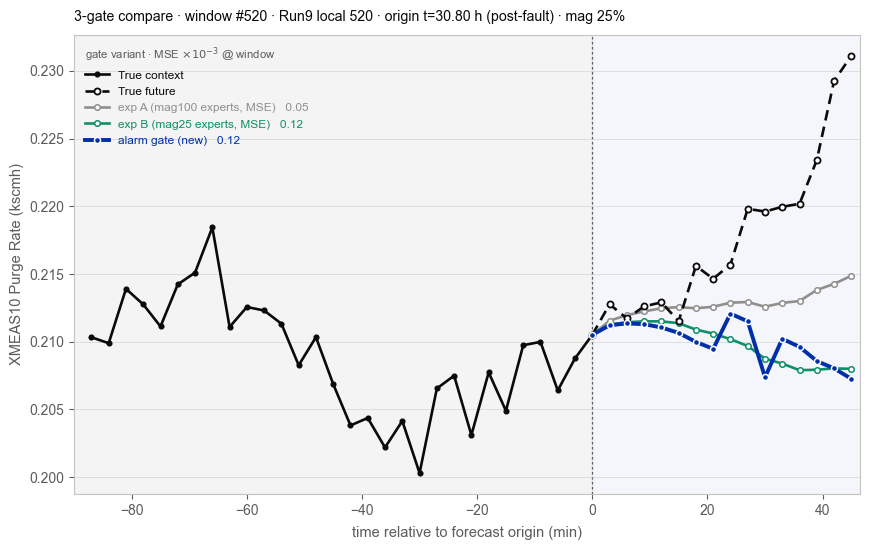

窗口#520 Run9 local520 origin30.80h (post-fault) — MSE@15 x1e-3: {'expA': 0.05, 'expB': 0.12, 'alarm': 0.12}


In [7]:
# 单窗口三方对比:改 run/local 或 index。找报警相关窗口可先用 alarm_windows(run=9)
plot_gate3(run=9, local=520);

## ▶ 主作图区 A — 按全局 index 作图(推理默认 mag=25)
改 `index`、`show_weights` 即可;下面所有推理作图**默认 `mag=25`**(小幅度故障)。
想看原始满幅度就传 `mag=100`(那档才有 DL baselines,可用 `models="all"`)。
**注意窗口范围随 mag 变**:mag=25 每 run 1809(全局 0–3617),mag=100 每 run 1810(0–3619)。

/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


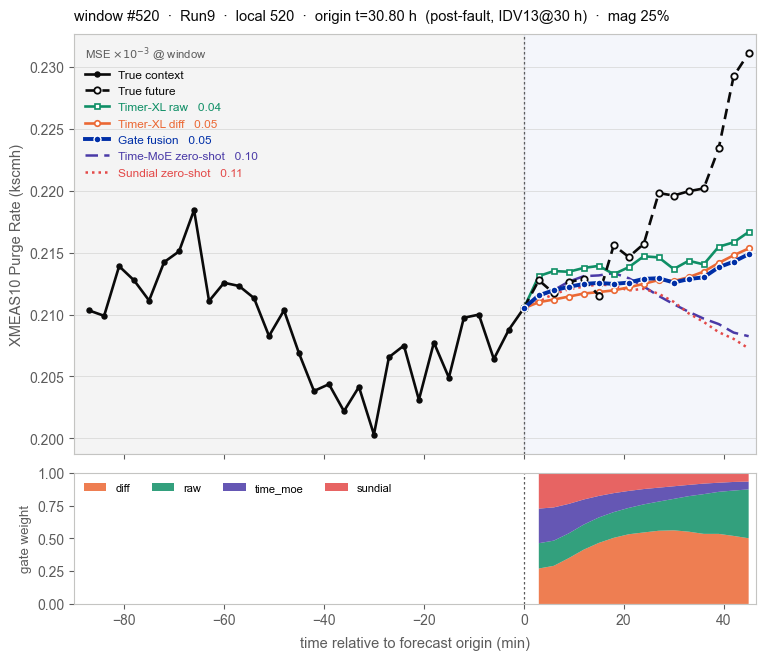

窗口#520  Run9  local520  origin 30.80h  (post-fault)  mag25%
  raw                    MSE@15 =    0.040 x1e-3
  diff                   MSE@15 =    0.051 x1e-3
  gate                   MSE@15 =    0.054 x1e-3
  time_moe               MSE@15 =    0.102 x1e-3
  sundial                MSE@15 =    0.109 x1e-3


In [8]:
plot_forecast(index=520, models="gate_experts", show_weights=True);          # mag=25 (默认)
# plot_forecast(index=526, mag=100, models="main", show_weights=True);          # 原始满幅度对比

## ▶ 主作图区 B — 按 run + local 作图
`run=9`(全局前半)或 `run=10`(全局后半),`local` 是该 run 内局部序号。

/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


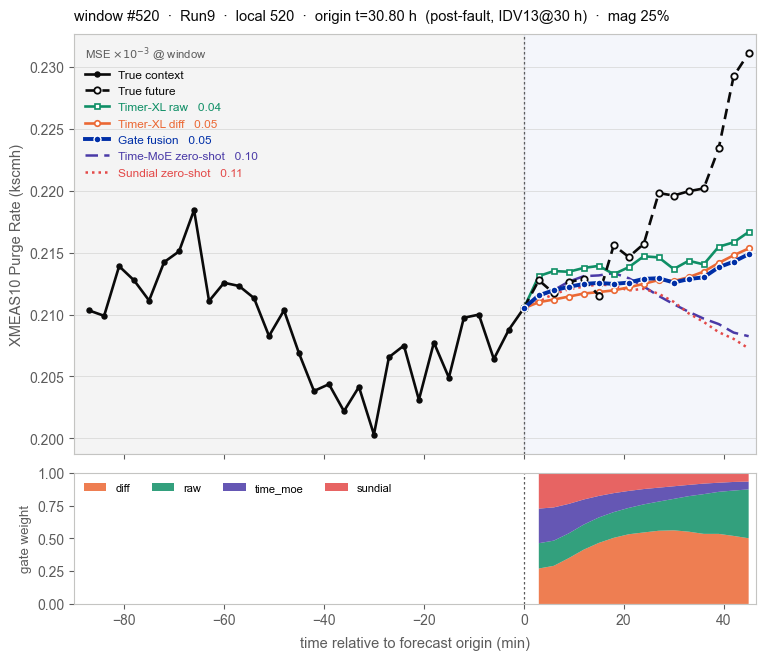

窗口#520  Run9  local520  origin 30.80h  (post-fault)  mag25%
  raw                    MSE@15 =    0.040 x1e-3
  diff                   MSE@15 =    0.051 x1e-3
  gate                   MSE@15 =    0.054 x1e-3
  time_moe               MSE@15 =    0.102 x1e-3
  sundial                MSE@15 =    0.109 x1e-3


In [9]:
plot_forecast(run=9, local=520, models="gate_experts");

## ▶ 单窗口 gate 路由详图
只看某个窗口 gate 在 15 步上如何分配 4 个专家(默认 mag=25)。

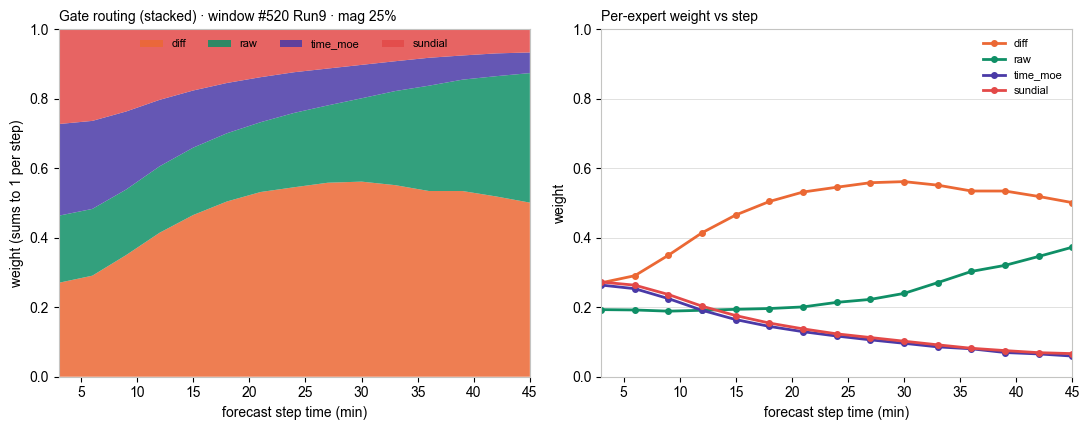

每步主导专家: 步1(+3min)=sundial, 步2(+6min)=diff, 步3(+9min)=diff, 步4(+12min)=diff, 步5(+15min)=diff, 步6(+18min)=diff, 步7(+21min)=diff, 步8(+24min)=diff, 步9(+27min)=diff, 步10(+30min)=diff, 步11(+33min)=diff, 步12(+36min)=diff, 步13(+39min)=diff, 步14(+42min)=diff, 步15(+45min)=diff


In [10]:
plot_gate_weights(index=520);

## ▶ 全测试集平均路由(方法可解释性主图)
一张图看 gate 在这一档幅度下的时域分工(默认 mag=25;传 `mag=100` 看满幅度版)。

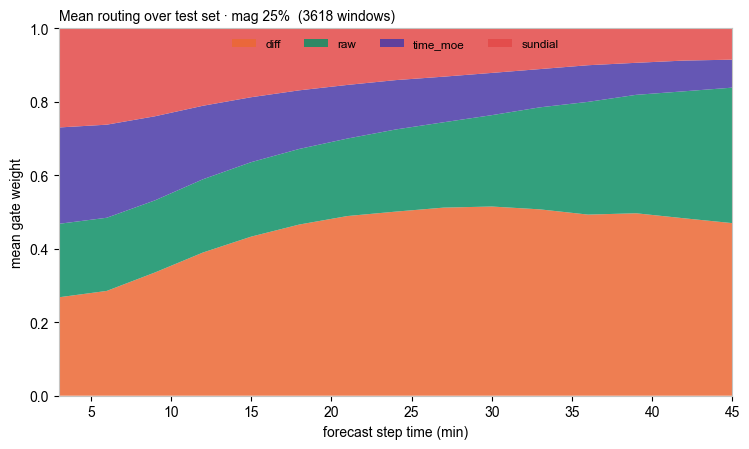

near h1-5 平均 : {'diff': 0.342, 'raw': 0.199, 'time_moe': 0.224, 'sundial': 0.234}
far  h11-15平均: {'diff': 0.49, 'raw': 0.324, 'time_moe': 0.09, 'sundial': 0.096}


In [11]:
plot_mean_routing();

## 🔎 快速定位"报警相关"窗口
列出某 run 里**真值未来 15 步会越限**的窗口(报警相关),便于挑演示窗口(默认 mag=25)。
返回 DataFrame:`global_idx` 可直接喂给 `plot_forecast(index=...)`。

In [12]:
def alarm_windows(run=9, ratio="r1p0", mag=MAG, first_n=25):
    wpr = windows_per_run(mag); off = 0 if run == 9 else wpr
    gd = result_dir("gate", ratio, mag)
    true = np.load(gd / "true.npy")[off:off+wpr, :HORIZON, 0]
    pred = np.load(gd / "pred.npy")[off:off+wpr, :HORIZON, 0]
    cross = lambda a: (a < LCL) | (a > UCL)
    tc, pc = cross(true), cross(pred)
    rows = []
    for l in range(wpr):
        if tc[l].any():
            rows.append(dict(global_idx=off + l, run=run, local=l,
                             origin_h=round((SEQ_LEN + l) * 0.05, 2),
                             true_alarm_step=int(np.argmax(tc[l])) + 1,
                             gate_alarm=bool(pc[l].any()),
                             gate_alarm_step=(int(np.argmax(pc[l])) + 1 if pc[l].any() else None)))
    df = pd.DataFrame(rows)
    print(f"Run{run} mag{mag}%: {len(df)} 个真值越限窗口(共 {wpr})。最早若干个:")
    return df.head(first_n)

alarm_windows(run=9)

Run9 mag25%: 1124 个真值越限窗口(共 1809)。最早若干个:


,global_idx,run,local,origin_h,true_alarm_step,gate_alarm,gate_alarm_step
0,522,9,522,30.90,15,False,NaN
1,523,9,523,30.95,14,False,NaN
2,524,9,524,31.00,13,False,NaN
3,525,9,525,31.05,12,False,NaN
4,526,9,526,31.10,11,False,NaN
5,527,9,527,31.15,10,False,NaN
6,528,9,528,31.20,9,False,NaN
7,529,9,529,31.25,8,False,NaN
8,530,9,530,31.30,7,False,NaN
9,531,9,531,31.35,6,False,NaN


## 🔬 测试集全程:XMEAS10 purge flow vs ±3σ 报警限(可选故障幅度)
看真值 purge flow 在整个测试集(Run9 / Run10)上如何越限。红色竖条=真值越 3σ(报警)时段,
紫色点划线=IDV13 注入(30 h),绿色带=限内健康区。标题给出越限点占比与首次越限时刻——
可直观看到"越 3σ 的时段"和"故障注入后"并不完全等同(尾部信号会缩回限内)。

**故障幅度 `mag`**:`mag=100` 读原始 `csv_5var`;`mag=25/50/75` 读 `csv_5var_lowmag`
(由 `dataset/TEP/code/tep_loader.py` 从 h5 导出的小幅度 IDV13)。**mag=25 已跑完整推理**
(gate+4 专家,见上文指标与作图);50/75 目前只有真值序列。**四档共用同一套 ±3σ 控制限**
(限来自故障前健康段,与幅度无关),对比才公平。
`plot_mag_compare(run=9)` 把同一个 run 的 100/75/50/25 叠起来看——幅度越小,越限越少、越晚、越浅。

saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/test_series_vs_limits_mag100.png


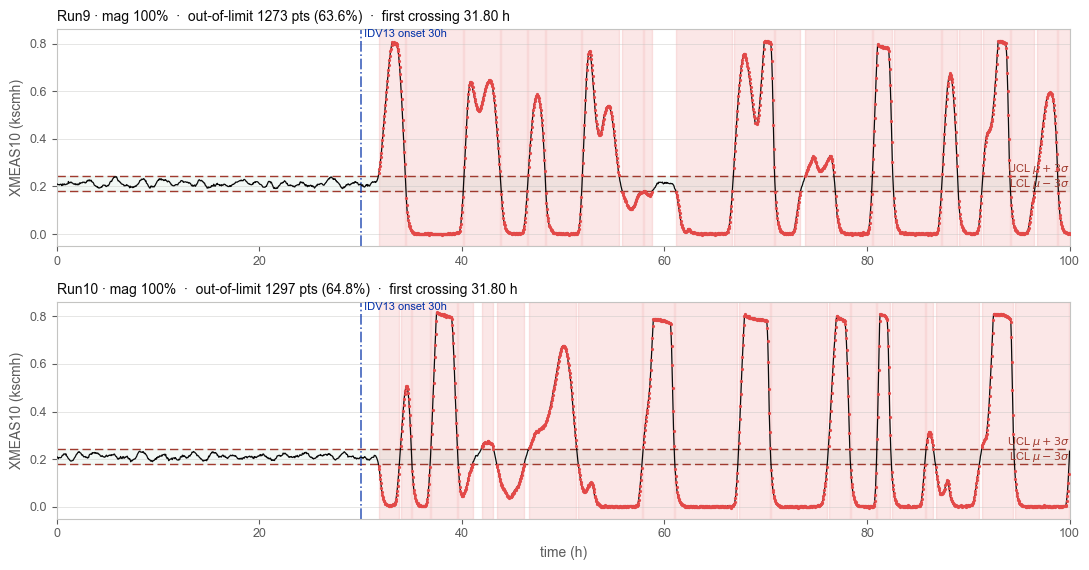

mag100% Run9: 越限 1273/2001 (63.6%), peak 0.812, 首次越限 31.80 h
mag100% Run10: 越限 1297/2001 (64.8%), peak 0.816, 首次越限 31.80 h


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/mag_compare_Run9.png


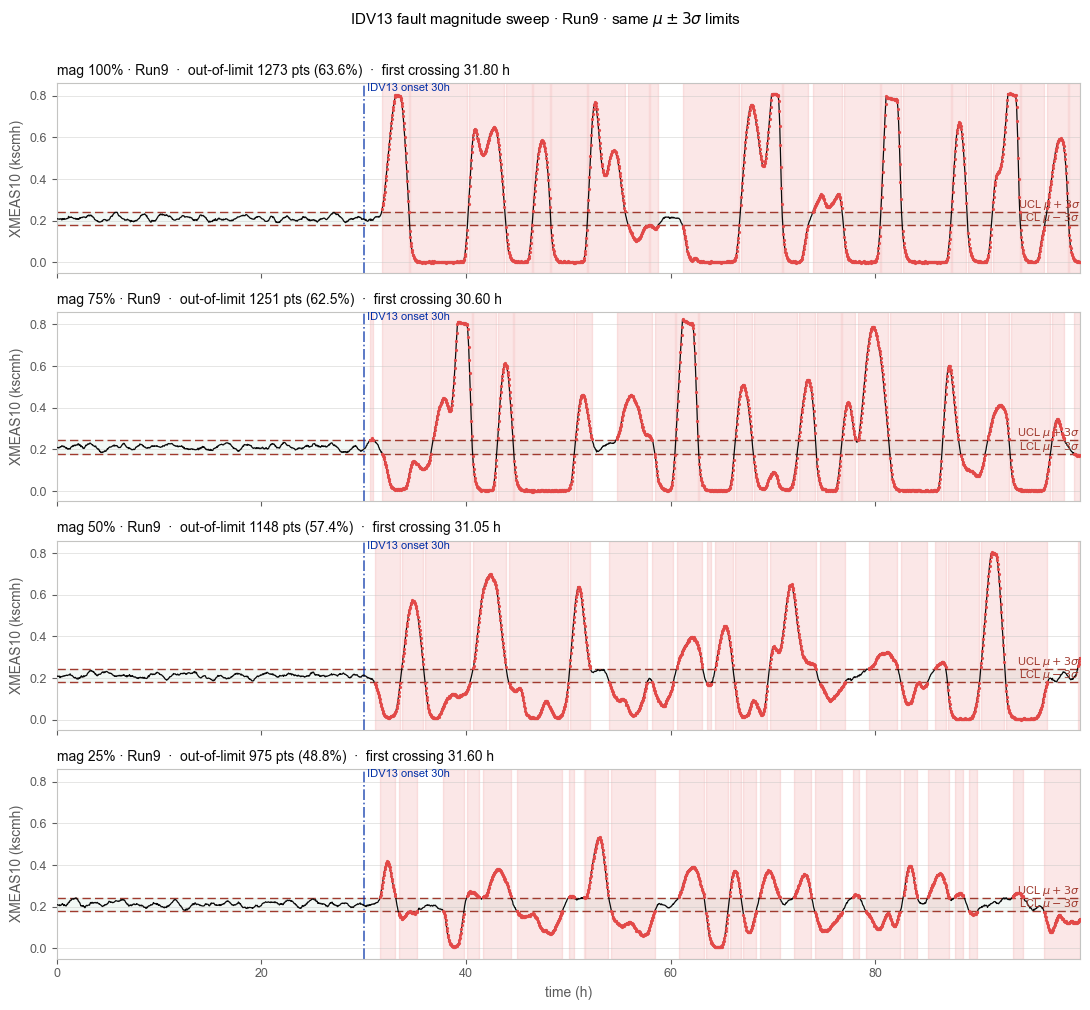

mag100% Run9: 越限 1273/2001 (63.6%), peak 0.812, 首次越限 31.80 h
mag75% Run9: 越限 1251/2000 (62.5%), peak 0.825, 首次越限 30.60 h
mag50% Run9: 越限 1148/2000 (57.4%), peak 0.804, 首次越限 31.05 h
mag25% Run9: 越限 975/2000 (48.8%), peak 0.534, 首次越限 31.60 h


In [13]:
def _draw_series_ax(ax, s, title, mark_points=True, ylim=(-0.05, 0.86)):
    t = np.arange(len(s)) * 0.05
    over = (s > UCL) | (s < LCL)
    ax.axhspan(LCL, UCL, color="#2e8b57", alpha=0.06, zorder=0)                    # 限内健康带
    ax.fill_between(t, 0, 1, where=over, transform=ax.get_xaxis_transform(),
                    color="#e34948", alpha=0.13, zorder=1)                          # 越限时段
    ax.plot(t, s, color=INK, lw=0.9, zorder=3)
    if mark_points:
        ax.plot(t[over], s[over], ls="none", marker=".", ms=2.6, color="#e34948", zorder=4)
    for yv, name, sg in ((LCL, "LCL", "-"), (UCL, "UCL", "+")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), zorder=2)
        ax.text(t[-1], yv, f" {name} " + r"$\mu%s3\sigma$" % sg, fontsize=8,
                color="#a03a2e", va="bottom", ha="right")
    ax.axvline(30.0, color=IKB, ls="-.", lw=1.2, alpha=0.75, zorder=2)
    ax.text(30.0, 1.0, " IDV13 onset 30h", fontsize=8, color=IKB, va="top", ha="left",
            transform=ax.get_xaxis_transform())
    frac = 100 * over.mean()
    first_txt = f"first crossing {t[over][0]:.2f} h" if over.any() else "no crossing"
    ax.set_title(f"{title}  ·  out-of-limit {int(over.sum())} pts ({frac:.1f}%)  ·  {first_txt}",
                 fontsize=10, loc="left", color=INK)
    ax.set_ylabel("XMEAS10 (kscmh)", fontsize=10, color=GREY_DARK)
    ax.set_xlim(0, t[-1]); ax.set_ylim(*ylim)
    ax.grid(axis="y", color=GREY_LIGHT, lw=0.6, alpha=0.5)
    for spn in ax.spines.values(): spn.set_color(GREY_LIGHT)
    ax.tick_params(colors=GREY_DARK, labelsize=9)

def _series_stats(run, mag):
    s = _csv_series(run, mag); over = (s > UCL) | (s < LCL)
    msg = f"mag{mag}% Run{run}: 越限 {int(over.sum())}/{len(s)} ({100*over.mean():.1f}%), peak {s.max():.3f}"
    if over.any():
        msg += f", 首次越限 {np.flatnonzero(over)[0]*0.05:.2f} h"
    return msg

def plot_test_series(runs=(9, 10), mag=100, mark_points=True, save=False):
    '''测试集上 XMEAS10 真值 vs ±3σ 报警限。runs 传 9 / 10 / (9,10);mag in {100,75,50,25}。'''
    runs = [runs] if isinstance(runs, int) else list(runs)
    fig, axes = plt.subplots(len(runs), 1, figsize=(11, 2.9 * len(runs)), squeeze=False)
    for ax, run in zip(axes[:, 0], runs):
        _draw_series_ax(ax, _csv_series(run, mag), f"Run{run} · mag {mag}%", mark_points)
    axes[-1, 0].set_xlabel("time (h)", fontsize=10, color=GREY_DARK)
    fig.tight_layout()
    if save:
        for ext in ("png", "pdf"):
            fig.savefig(HERE / f"test_series_vs_limits_mag{mag}.{ext}", dpi=300, facecolor=PAPER)
        print("saved:", HERE / f"test_series_vs_limits_mag{mag}.png")
    plt.show()
    for run in runs: print(_series_stats(run, mag))
    return fig

def plot_mag_compare(run=9, mags=(100, 75, 50, 25), mark_points=True, save=False):
    '''同一个 run 在不同故障幅度下的 XMEAS10 vs ±3σ,叠放对比(限相同)。'''
    mags = list(mags)
    fig, axes = plt.subplots(len(mags), 1, figsize=(11, 2.5 * len(mags)), squeeze=False, sharex=True)
    for ax, mag in zip(axes[:, 0], mags):
        try:
            _draw_series_ax(ax, _csv_series(run, mag), f"mag {mag}% · Run{run}", mark_points)
        except FileNotFoundError as e:
            ax.text(0.5, 0.5, str(e), ha="center", va="center", transform=ax.transAxes)
    axes[-1, 0].set_xlabel("time (h)", fontsize=10, color=GREY_DARK)
    fig.suptitle(f"IDV13 fault magnitude sweep · Run{run} · same " + r"$\mu\pm3\sigma$ limits",
                 y=1.005, fontsize=11)
    fig.tight_layout()
    if save:
        for ext in ("png", "pdf"):
            fig.savefig(HERE / f"mag_compare_Run{run}.{ext}", dpi=300, facecolor=PAPER)
        print("saved:", HERE / f"mag_compare_Run{run}.png")
    plt.show()
    for mag in mags:
        try: print(_series_stats(run, mag))
        except FileNotFoundError: print(f"mag{mag}%: 缺 csv")
    return fig

plot_test_series(runs=(9, 10), mag=100, save=True)
plot_mag_compare(run=9, mags=(100, 75, 50, 25), save=True);

## 📦 批量导出
把若干窗口一次性存成 300 dpi png + pdf 到本文件夹。

/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/pred_idx520_mag25_w.png


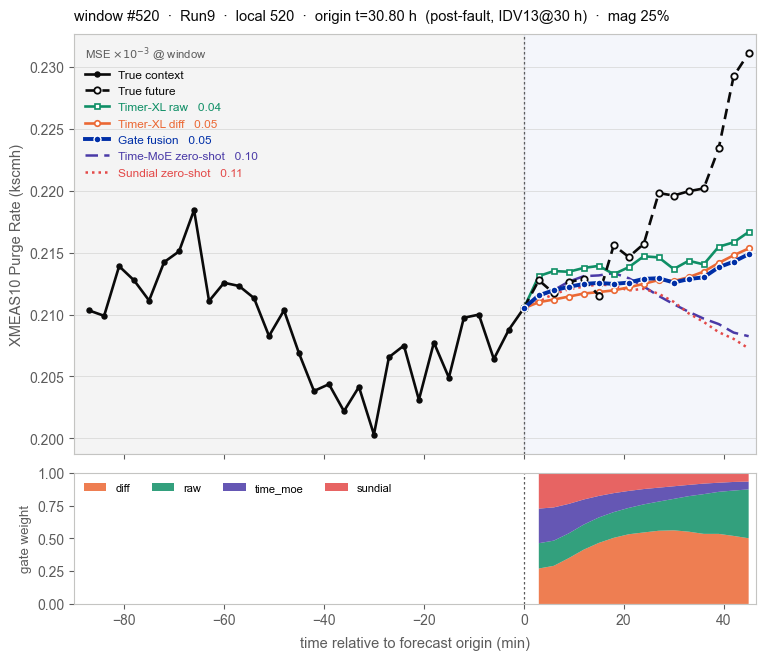

窗口#520  Run9  local520  origin 30.80h  (post-fault)  mag25%
  raw                    MSE@15 =    0.040 x1e-3
  diff                   MSE@15 =    0.051 x1e-3
  gate                   MSE@15 =    0.054 x1e-3
  time_moe               MSE@15 =    0.102 x1e-3
  sundial                MSE@15 =    0.109 x1e-3


/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/pred_idx522_mag25_w.png


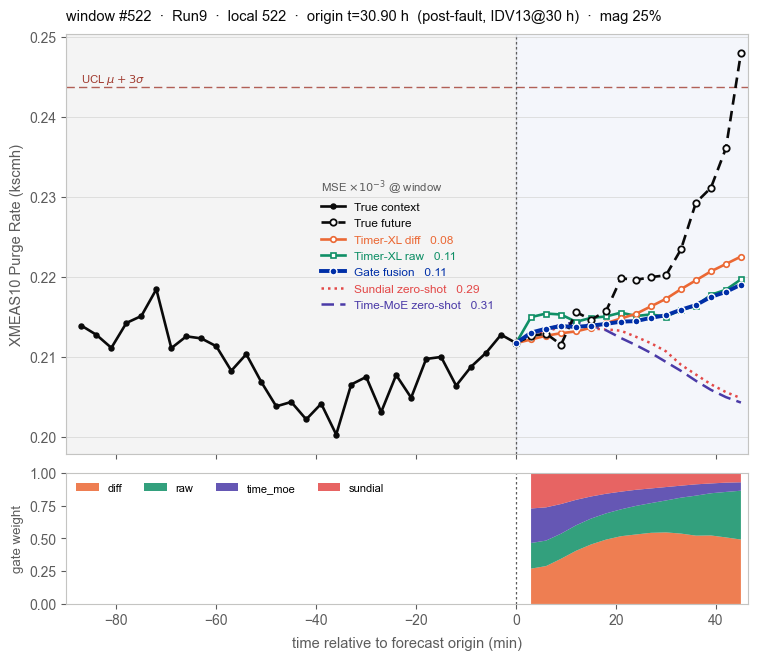

窗口#522  Run9  local522  origin 30.90h  (post-fault)  mag25%
  diff                   MSE@15 =    0.077 x1e-3
  raw                    MSE@15 =    0.109 x1e-3
  gate                   MSE@15 =    0.112 x1e-3
  sundial                MSE@15 =    0.288 x1e-3
  time_moe               MSE@15 =    0.305 x1e-3


/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/pred_idx526_mag25_w.png


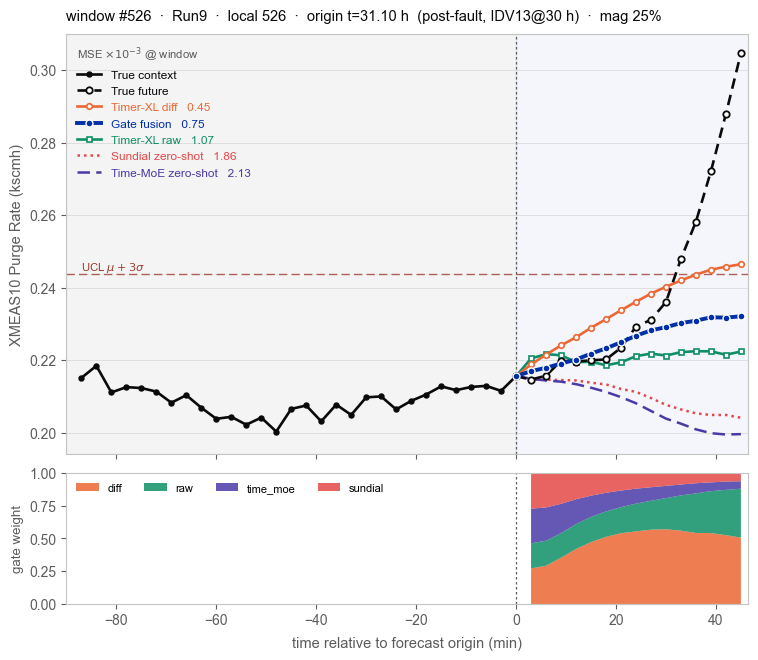

窗口#526  Run9  local526  origin 31.10h  (post-fault)  mag25%
  diff                   MSE@15 =    0.446 x1e-3
  gate                   MSE@15 =    0.747 x1e-3
  raw                    MSE@15 =    1.071 x1e-3
  sundial                MSE@15 =    1.862 x1e-3
  time_moe               MSE@15 =    2.131 x1e-3


/tmp/ipykernel_2558942/1102295631.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/pred_idx528_mag25_w.png


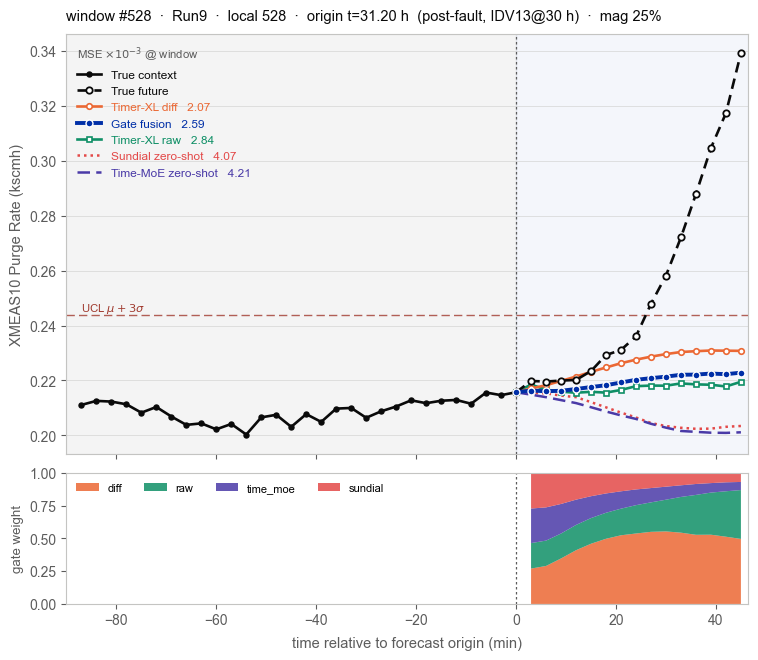

窗口#528  Run9  local528  origin 31.20h  (post-fault)  mag25%
  diff                   MSE@15 =    2.070 x1e-3
  gate                   MSE@15 =    2.592 x1e-3
  raw                    MSE@15 =    2.845 x1e-3
  sundial                MSE@15 =    4.066 x1e-3
  time_moe               MSE@15 =    4.209 x1e-3


In [14]:
for idx in [520, 522, 526, 528]:
    plot_forecast(index=idx, models="gate_experts", show_weights=True, save=True)   # mag=25 (默认)